In [12]:
import numpy as np  # Support for large, multi-dimensional arrays and matrices
import matplotlib.pyplot as plt  # Useful plotting tool for data visualization
from mpl_toolkits.mplot3d import axes3d  # Used for plotting 3D graph
import numpy.linalg as la  # General linear algebra package

In [13]:
# Defines a function f(x), which takes an input array x and returns a scalar value.
def f(x):
    # Define the objective function
    return x[0] ** 2 + x[0] * x[1] + 3 * x[1] ** 2  # python starts indexing from 0!

#Defines the gradient df(x) of f(x). It returns the derivative of f with respect to x.
def df(x):
    # Define the gradient of the objective function
    return np.array([2 * x[0] + x[1], x[0] + 6 * x[1]])

Hessian = np.array([[2,1],[1,6]])
Hessian_inverse = np.linalg.inv(Hessian)

In [8]:
Hessian_inverse

array([[ 0.54545455, -0.09090909],
       [-0.09090909,  0.18181818]])

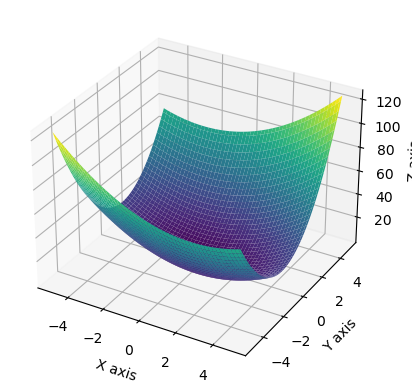

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')  # Correct way to create a 3D axis

# Now you can use ax to plot in 3D
# For example:
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = X** 2 + X* Y + 3 * Y ** 2

ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')

plt.show()

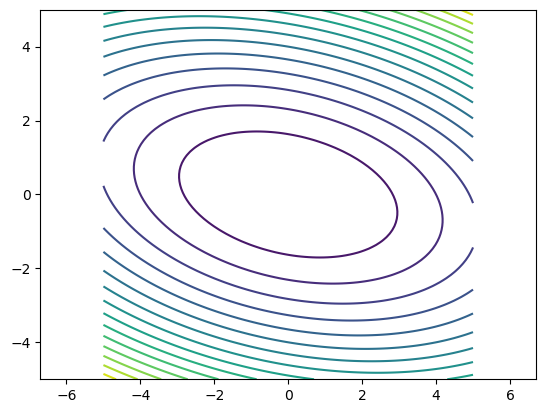

In [ ]:
# Commands to plot the contour graph of the function
plt.figure(2)
plt.axis("equal")  # The "equal" ensures that the increments of x and y are the same.
plt.contour(X, Y, Z, 15)  # Plot the contour lines for the meshes. The 15 indicates the number and position of the lines.

In [17]:
#Gradient Descent Initialization
points = [np.array([3, 3])]  # Create a list of points, called "points", and store an initial point "x" into it
tol = 1e-6  # termination tolerance
            #( The algorithm will stop iterating when change in the function's value becomes smaller than this tolerance value, indicating that it has potentially reached or is very close to a minimum)
maxiter = 1000  # maximum number of allowed iterations
dxmin = 1e-6  # minimum allowed perturbation
            # dxmin is set to 1e-6, which means that if the change in the position of the variable x from one iteration to the next is smaller than 0.000001, the algorithm may conclude that it is no longer making meaningful progress towards the minimum. This could be an indication that the algorithm has reached or is very close to a point of minimum change (a potential minimum of the function


dx = float('Inf')  # set dx as a very large number
gnorm = float('Inf')  # set gnorm as a very large number
# For dx and gnorm these are common practice to ensure that the initial conditions don't cause premature termination of
#the algorithm. As the algorithm progresses, these values will be updated with actual computed values.

count = 0  # set iteration counter
t_opt = 1  # Set fixed step size

The current point is:  [3 3]
g = [ -9 -21]
The current point is:  [8.8817842e-16 0.0000000e+00]
g = [-1.77635684e-15 -8.88178420e-16]
Numbers of iterations:  1


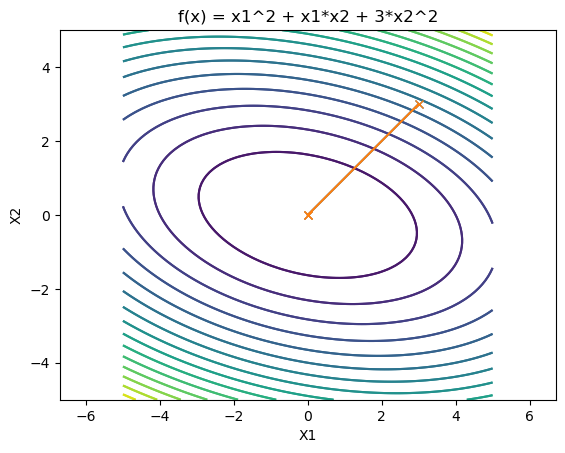

In [18]:
# Main while loop: stay in this loop, while none of the following three conditions are satisfied:
# 1) The gradient norm is sufficiently larger than zero
# 2) count is less than the max iteration count; and
# 3) The change from x to the next point, is sufficiently large

while (gnorm >= tol and (count <= maxiter and dx >= dxmin)):
    x = points[-1]  # Always set x equal to the most recently placed point (this is done by indexing with "-1")
    g = -1 * df(x)  # For minimization problems, the negative of the gradient is the best improving direction
    step_direction = np.dot(Hessian_inverse, g)
    next_point = x + t_opt * step_direction  # Update next point
    points.append(next_point)  # Append next_point to list of points

    # Update termination conditions
    gnorm = la.norm(-g)  # Compute norm of gradient (using the la package; one could also write out the L2 norm)
    dx = la.norm(
        next_point - x)  # Compute the length (norm) of the difference vector between the last point x, and the next point
    count = count + 1  # Increment the iteration count

    # Output information for user
    print("The current point is: ", x)
    print("g =", g)

    # Commands for plotting
    plt.figure(3)
    plt.axis("equal")
    plt.contour(X, Y, Z, 15)
    it_array = np.array(points)  # Creates an array object with the points.
    plt.plot(it_array.T[0], it_array.T[1], "x-")  # plot current point

    # Set plot title, x and y label
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title("f(x) = x1^2 + x1*x2 + 3*x2^2")

# Final output to user
print("Numbers of iterations: ", count - 1)

# Command to show the generated plots
plt.show(True)